# Golden-scale self-similarity functional

This notebook implements a discrete approximation of the golden-scale self-similarity functional $S_{N,m}$ introduced in `pattern_search_in_mandelbrot.md`. It samples a binary image of the Mandelbrot set, builds a signed distance field, and searches for points whose normalized neighborhoods are approximately invariant under the scale sequence $r_n = r_0 \lambda^{-2n}$.

In [1]:
import math
from matplotlib.patches import Rectangle

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import distance_transform_edt, map_coordinates

PHI = (1.0 + math.sqrt(5.0)) / 2.0
plt.rcParams['figure.dpi'] = 120


This cell loads the numerical and plotting tools. The constant `PHI` is the golden ratio
$$
\lambda = \frac{1+\sqrt{5}}{2},
$$
which is the scale parameter appearing in the functional. The cell has no printed output; it only prepares the environment.

In [2]:
def mandelbrot_indicator(bounds, n, max_iter=200):
    xmin, xmax, ymin, ymax = bounds
    dx = (xmax - xmin) / n
    dy = (ymax - ymin) / n
    xs = xmin + (np.arange(n) + 0.5) * dx
    ys = ymin + (np.arange(n) + 0.5) * dy
    c = xs[None, :] + 1j * ys[:, None]
    z = np.zeros_like(c)
    inside = np.ones(c.shape, dtype=bool)
    for _ in range(max_iter):
        z[inside] = z[inside] * z[inside] + c[inside]
        inside[inside] = np.abs(z[inside]) <= 2.0
    return inside.astype(np.uint8)


def signed_distance(indicator, spacing):
    inside = indicator.astype(bool)
    return distance_transform_edt(inside, sampling=spacing) - distance_transform_edt(~inside, sampling=spacing)


def unit_disk_grid(patch_size):
    grid = np.linspace(-1.0, 1.0, patch_size)
    u, v = np.meshgrid(grid, grid, indexing='xy')
    mask = u * u + v * v <= 1.0
    return u, v, mask


def sample_field(field, bounds, x_coords, y_coords):
    xmin, xmax, ymin, ymax = bounds
    ny, nx = field.shape
    col = (x_coords - xmin) / (xmax - xmin) * nx - 0.5
    row = (y_coords - ymin) / (ymax - ymin) * ny - 0.5
    return map_coordinates(field, [row, col], order=1, mode='nearest')


def normalized_patch(field, bounds, center, radius, patch_size):
    x0, y0 = center
    u, v, mask = unit_disk_grid(patch_size)
    x = x0 + radius * u
    y = y0 + radius * v
    patch = sample_field(field, bounds, x, y)
    patch[~mask] = 0.0
    return patch, mask


def rotate_patch(patch, angle, mask):
    patch_size = patch.shape[0]
    u, v, _ = unit_disk_grid(patch_size)
    c = math.cos(angle)
    s = math.sin(angle)
    x = c * u - s * v
    y = s * u + c * v
    rotated = sample_field(patch, (-1.0, 1.0, -1.0, 1.0), x, y)
    rotated[~mask] = 0.0
    return rotated


def patch_l2_error(patch_a, patch_b, mask):
    diff = patch_a - patch_b
    return math.sqrt(np.mean(np.square(diff[mask])))


def golden_scale_self_similarity(field, bounds, center, r0, m=3, patch_size=40, angle_samples=16):
    base_patch, mask = normalized_patch(field, bounds, center, r0, patch_size)
    angles = np.linspace(0.0, 2.0 * math.pi, angle_samples, endpoint=False)
    rotated_base = [(angle, rotate_patch(base_patch, angle, mask)) for angle in angles]
    errors = []
    patches = {0: base_patch}
    matches = {}
    for n in range(1, m + 1):
        radius = r0 * PHI ** (-2 * n)
        patch, _ = normalized_patch(field, bounds, center, radius, patch_size)
        patches[n] = patch
        best_value = math.inf
        best_angle = 0.0
        best_match = None
        for angle, rotated in rotated_base:
            value = patch_l2_error(patch, rotated, mask)
            if value < best_value:
                best_value = value
                best_angle = angle
                best_match = rotated
        errors.append({'n': n, 'radius': radius, 'angle': best_angle, 'value': best_value})
        matches[n] = best_match
    score = sum((2.0 ** (-item['n'])) * item['value'] for item in errors)
    return {
        'center': center,
        'score': score,
        'errors': errors,
        'patches': patches,
        'matches': matches,
        'mask': mask,
    }


def search_grid(field, bounds, search_bounds, r0, m=3, patch_size=40, angle_samples=16, grid_shape=(17, 17)):
    xmin, xmax, ymin, ymax = search_bounds
    xs = np.linspace(xmin, xmax, grid_shape[0])
    ys = np.linspace(ymin, ymax, grid_shape[1])
    scores = np.empty((len(ys), len(xs)))
    best = None
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            result = golden_scale_self_similarity(
                field,
                bounds,
                (x, y),
                r0,
                m=m,
                patch_size=patch_size,
                angle_samples=angle_samples,
            )
            scores[j, i] = result['score']
            if best is None or result['score'] < best['score']:
                best = result
    return xs, ys, scores, best


def sampled_local_minima(xs, ys, scores):
    minima = []
    ny, nx = scores.shape
    for j in range(ny):
        for i in range(nx):
            j0 = max(0, j - 1)
            j1 = min(ny, j + 2)
            i0 = max(0, i - 1)
            i1 = min(nx, i + 2)
            neighborhood = scores[j0:j1, i0:i1]
            value = scores[j, i]
            if value == np.min(neighborhood):
                minima.append({'center': (xs[i], ys[j]), 'score': value})
    minima.sort(key=lambda item: item['score'])
    return minima


This cell implements the discrete model. The functions do the following:

- `mandelbrot_indicator` constructs the binary image $I_N$.
- `signed_distance` constructs the signed distance field $\delta_N$.
- `normalized_patch` samples the rescaled field $f_{N,x,n}$ on the closed unit disk.
- `rotate_patch` and `patch_l2_error` discretize the rotation minimization and the $L^2$ discrepancy.
- `golden_scale_self_similarity` computes the score $S_{N,m}(x)$ at a fixed point $x$.
- `search_grid` evaluates this score on a finite grid inside the prescribed search region.

This cell also has no printed output, because it only defines the operators used later.

In [3]:
BOUNDS = (-1.6, 0.4, -0.9, 0.9)
SEARCH_BOUNDS = (-1.05, -0.55, -0.35, 0.35)
N = 320
MAX_ITER = 200
R0 = 0.18
M = 3
PATCH_SIZE = 40
ANGLE_SAMPLES = 16
GRID_SHAPE = (17, 17)

indicator = mandelbrot_indicator(BOUNDS, N, max_iter=MAX_ITER)
dx = (BOUNDS[1] - BOUNDS[0]) / N
dy = (BOUNDS[3] - BOUNDS[2]) / N
field = signed_distance(indicator, spacing=(dy, dx))

grid_xs, grid_ys, score_grid, best = search_grid(
    field,
    BOUNDS,
    SEARCH_BOUNDS,
    R0,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)
local_minima = sampled_local_minima(grid_xs, grid_ys, score_grid)

print('Best center:', best['center'])
print('Best score:', round(best['score'], 6))
for item in best['errors']:
    print('n =', item['n'], 'radius =', round(item['radius'], 6), 'angle =', round(item['angle'], 6), 'error =', round(item['value'], 6))
print('Number of sampled local minima:', len(local_minima))
for item in local_minima:
    print('candidate center =', tuple(round(v, 6) for v in item['center']), 'score =', round(item['score'], 6))


Best center: (np.float64(-0.8), np.float64(0.0))
Best score: 0.037588
n = 1 radius = 0.068754 angle = 0.0 error = 0.039243
n = 2 radius = 0.026262 angle = 0.0 error = 0.046519
n = 3 radius = 0.010031 angle = 0.0 error = 0.050693
Number of sampled local minima: 11
candidate center = (np.float64(-0.8), np.float64(0.0)) score = 0.037588
candidate center = (np.float64(-0.83125), np.float64(-0.0875)) score = 0.040543
candidate center = (np.float64(-0.83125), np.float64(0.0875)) score = 0.040543
candidate center = (np.float64(-0.7375), np.float64(-0.30625)) score = 0.043004
candidate center = (np.float64(-0.7375), np.float64(0.30625)) score = 0.043004
candidate center = (np.float64(-1.05), np.float64(0.21875)) score = 0.043826
candidate center = (np.float64(-1.05), np.float64(-0.21875)) score = 0.043826
candidate center = (np.float64(-1.05), np.float64(-0.30625)) score = 0.044107
candidate center = (np.float64(-1.05), np.float64(0.30625)) score = 0.044107
candidate center = (np.float64(-0.61

This cell fixes the numerical parameters and evaluates the functional on the search grid. In the present run the best sampled point is
$$
x_{N,m} = (-0.8,0.0),
$$
with score approximately
$$
S_{N,m}(x_{N,m}) \approx 0.037588.
$$
The three reported radii are exactly the scales
$$
r_n = r_0 \lambda^{-2n}, \qquad n=1,2,3.
$$
All optimal angles are $0$ in this coarse experiment, so the best match occurs without an additional rotation among the sampled angles. The errors increase slightly with $n$, which is consistent with the fact that smaller scales are harder to resolve accurately on a finite grid.

The notebook also enumerates all sampled local minima of the score field on the finite grid $U \cap \Gamma_N$. This set is finite because the grid itself is finite. In a grid-based theory with candidate sets taken over the countable family of finite grids $(\Gamma_N)_{N \geq 1}$, the union of all sampled candidate sets is therefore at most countable.

The next cell displays all sampled local minima of $S_{N,m}$ on the chosen search grid. These are the discrete candidate Dudko-type patterns detected in the present experiment. Since the search grid is finite, the set displayed below is finite.

In [4]:
candidate_array = np.array([item['center'] for item in local_minima])
candidate_scores = np.array([item['score'] for item in local_minima])
print('All sampled candidate centers and scores:')
for item in local_minima:
    print(tuple(round(v, 6) for v in item['center']), round(item['score'], 6))


All sampled candidate centers and scores:
(np.float64(-0.8), np.float64(0.0)) 0.037588
(np.float64(-0.83125), np.float64(-0.0875)) 0.040543
(np.float64(-0.83125), np.float64(0.0875)) 0.040543
(np.float64(-0.7375), np.float64(-0.30625)) 0.043004
(np.float64(-0.7375), np.float64(0.30625)) 0.043004
(np.float64(-1.05), np.float64(0.21875)) 0.043826
(np.float64(-1.05), np.float64(-0.21875)) 0.043826
(np.float64(-1.05), np.float64(-0.30625)) 0.044107
(np.float64(-1.05), np.float64(0.30625)) 0.044107
(np.float64(-0.6125), np.float64(0.35)) 0.047231
(np.float64(-0.6125), np.float64(-0.35)) 0.047231


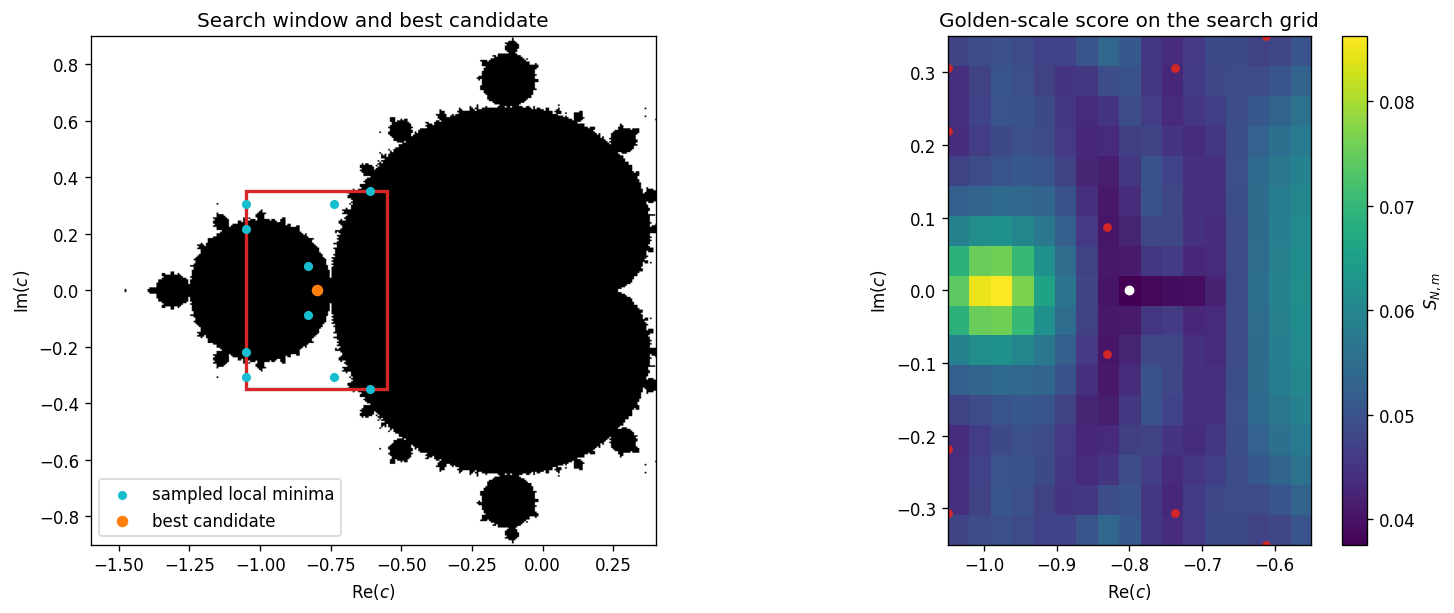

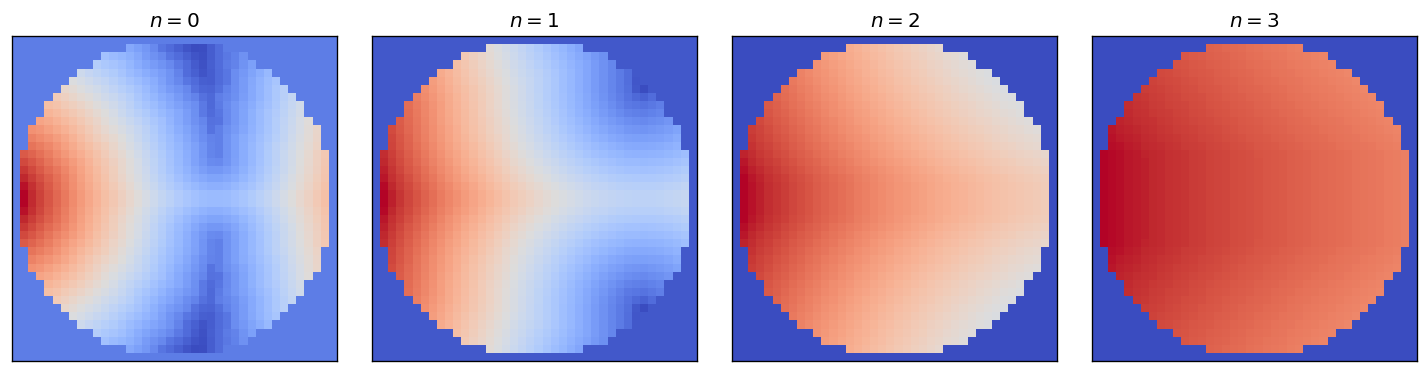

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

extent = (BOUNDS[0], BOUNDS[1], BOUNDS[2], BOUNDS[3])
axes[0].imshow(indicator, extent=extent, origin='lower', cmap='binary')
axes[0].add_patch(
    Rectangle(
        (SEARCH_BOUNDS[0], SEARCH_BOUNDS[2]),
        SEARCH_BOUNDS[1] - SEARCH_BOUNDS[0],
        SEARCH_BOUNDS[3] - SEARCH_BOUNDS[2],
        fill=False,
        edgecolor='tab:red',
        linewidth=2,
    )
)
axes[0].scatter(candidate_array[:, 0], candidate_array[:, 1], color='tab:cyan', s=20, label='sampled local minima')
axes[0].scatter([best['center'][0]], [best['center'][1]], color='tab:orange', s=35, label='best candidate')
axes[0].set_title('Search window and best candidate')
axes[0].set_xlabel(r'$\mathrm{Re}(c)$')
axes[0].set_ylabel(r'$\mathrm{Im}(c)$')
axes[0].legend(loc='lower left')

score_extent = (grid_xs[0], grid_xs[-1], grid_ys[0], grid_ys[-1])
im = axes[1].imshow(score_grid, extent=score_extent, origin='lower', cmap='viridis')
axes[1].scatter(candidate_array[:, 0], candidate_array[:, 1], color='tab:red', s=18)
axes[1].scatter([best['center'][0]], [best['center'][1]], color='white', s=24)
axes[1].set_title('Golden-scale score on the search grid')
axes[1].set_xlabel(r'$\mathrm{Re}(c)$')
axes[1].set_ylabel(r'$\mathrm{Im}(c)$')
fig.colorbar(im, ax=axes[1], label=r'$S_{N,m}$')
plt.show()

fig, axes = plt.subplots(1, M + 1, figsize=(3 * (M + 1), 3), constrained_layout=True)
for n in range(M + 1):
    axes[n].imshow(best['patches'][n], cmap='coolwarm', origin='lower')
    axes[n].set_title(r'$n = ' + str(n) + r'$')
    axes[n].set_xticks([])
    axes[n].set_yticks([])
plt.show()


This cell visualizes the computation.

1. The first panel shows the sampled Mandelbrot set, the rectangular search region, all sampled local minima of the score field, and the best candidate point returned by the grid search.
2. The second panel shows the scalar field $S_{N,m}$ on the search grid. Darker regions correspond to smaller values of the functional, hence to stronger multiscale self-similarity relative to the prescribed golden scaling. The overlaid red points are exactly the sampled local minima displayed in the previous cell.
3. The final row of panels shows the normalized patches $f_{N,x_{N,m},n}$ for $n=0,1,2,3$. Their visual resemblance is the geometric content captured by the functional: the closer these patches are after rescaling, the smaller the value of $S_{N,m}$.

In the present experiment the minimum is attained on the real axis near the center of the search window, and the normalized patches remain visibly similar across the first few golden scales.